# Лабораторная работа №1: CV

Для исследования выбран набор данных "Kvasir-SEG" (сегментация полипов при эндоскопических исследованиях).

Данная задача является классическим примером работы медицинских киберфизических систем. В роботизированной хирургии например, системы класса Da Vinci, компьютерное зрение используется для анализа видеопотока в реальном времени, автоматического обнаружения и сегментации аномалий для ассистирования хирургу или обеспечения автономных действий робота-манипулятора.
Метрики качества:

Intersection over Union (IoU / Индекс Жаккара) - основная метрика. Она показывает отношение площади пересечения предсказанной маски с истинной к их объединению.

Dice Coefficient (F1-score) - дополнительная метрика. Дает больший вес правильным предсказаниям целевого класса (полипа), что необходимо, так как целевой объект часто занимает малую долю площади всего кадра.

Подготовимся

Скачаем датасет из официального сайта. Код ниже скачает данные, создаст класс Dataset и разобьет данные на train/val

File ‘kvasir-seg.zip’ already there; not retrieving.

Всего изображений: 1000
Всего масок: 1000
Пример из обучающей выборки:


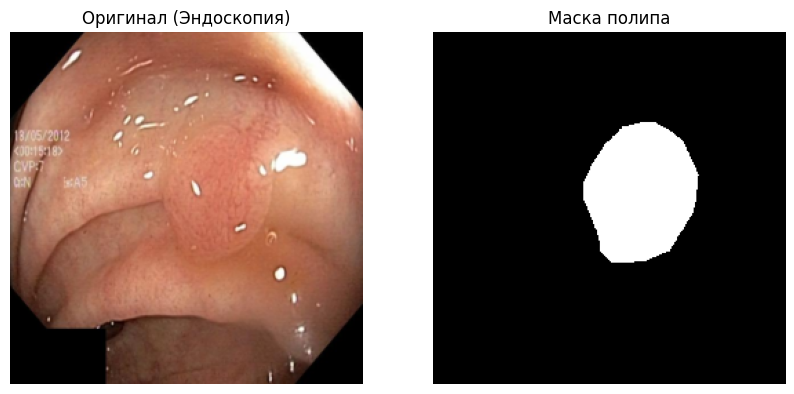

In [20]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

!wget -nc --no-check-certificate https://datasets.simula.no/downloads/kvasir-seg.zip
!unzip -n -q kvasir-seg.zip -d kvasir_data/

image_paths = sorted(glob.glob("kvasir_data/**/images/*.jpg", recursive=True) + glob.glob("kvasir_data/**/images/*.png", recursive=True))
mask_paths = sorted(glob.glob("kvasir_data/**/masks/*.jpg", recursive=True) + glob.glob("kvasir_data/**/masks/*.png", recursive=True))

print(f"Всего изображений: {len(image_paths)}")
print(f"Всего масок: {len(mask_paths)}")

train_img, val_img, train_mask, val_mask = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

# 2. Создание класса датасета
class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

        # Для бейзлайна используем стандартные трансформации torchvision
        self.transform_img = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(), # переводит в [0, 1]
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.transform_mask = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size), interpolation=Image.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L") # маска в grayscale

        image = self.transform_img(image)
        mask = self.transform_mask(mask)

        # Округление маски до 0 или 1 (бинарная классификация)
        mask = torch.where(mask > 0.5, 1.0, 0.0)

        return image, mask

# Создаем датасеты и даталоадеры
train_dataset = KvasirDataset(train_img, train_mask)
val_dataset = KvasirDataset(val_img, val_mask)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 3. Визуализация для проверки
def show_sample(dataset, idx=0):
    img, mask = dataset[idx]

    # Денормализация для визуализации
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    mask = mask.numpy().squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title("Оригинал (Эндоскопия)")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Маска полипа")
    axes[1].axis('off')
    plt.show()

print("Пример из обучающей выборки:")
show_sample(train_dataset, idx=5)


Всё скачалось. Теперь можем приступить к обучению моделей. Сначала загрузим нужную библиотеку, затем запустим следующую ячейку, он установит нужную библиотеку, задаст функции для подсчета наших метрик (IoU и Dice) и создаст универсальную функцию для обучения моделей.

Для сверточной модели (CNN) возьмем классическую архитектуру U-Net с энкодером ResNet34. Для трансформерной модели возьмем ту же архитектуру U-Net, но в качестве энкодера поставим Mix Vision Transformer (MiT) - mit_b0.

In [5]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


In [21]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

# 1. Функции для расчета метрик (IoU и Dice)
def calculate_metrics(preds, targets, threshold=0.5):
    # Применяем сигмоиду, так как выход модели - логиты
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    # Считаем пересечение и объединение
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection

    # Добавляем 1e-6 для избежания деления на ноль
    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2 * intersection + 1e-6) / (preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + 1e-6)

    return iou.mean().item(), dice.mean().item()

# 2. Универсальная функция для обучения
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # --- Обучение ---
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc="Training", leave=False):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)

        # --- Валидация ---
        model.eval()
        val_loss, val_iou, val_dice = 0.0, 0.0, 0.0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc="Validation", leave=False):
                images, masks = images.to(device), masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                iou, dice = calculate_metrics(outputs, masks)
                val_iou += iou
                val_dice += dice

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        val_dice /= len(val_loader)

        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_dice'].append(val_dice)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}\n")

    return history

Используем устройство: cuda


Теперь создаем и обучаем U-Net + ResNet34.
Я поставил всего 5 эпох, чтобы получить бейзлайн. Этого хватит, чтобы модель начала что-то понимать.

In [8]:
print("=== ОБУЧЕНИЕ CNN (U-Net + ResNet34) ===")

# Инициализируем модель
cnn_model = smp.Unet(
    encoder_name="resnet34",        # Сверточный энкодер
    encoder_weights="imagenet",     # Предобученные веса (Transfer Learning)
    in_channels=3,                  # RGB изображения
    classes=1                       # 1 класс (полип или фон)
).to(device)

# Функция потерь и оптимизатор
criterion = nn.BCEWithLogitsLoss() # Стандартная для бинарной сегментации
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-4)

# Запуск обучения
cnn_history = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_cnn,
    epochs=5
)

=== ОБУЧЕНИЕ CNN (U-Net + ResNet34) ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1/5


...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2008 | Val Loss: 0.2182 | Val IoU: 0.7295 | Val Dice: 0.8167

Epoch 5/5


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1739 | Val Loss: 0.2042 | Val IoU: 0.7443 | Val Dice: 0.8297



Запустим обучение модели с трансформерным энкодером mit_b0 (Mix Vision Transformer).

In [9]:
print("=== ОБУЧЕНИЕ TRANSFORMER (U-Net + MiT_b0) ===")

# Инициализируем модель с трансформерным энкодером
transformer_model = smp.Unet(
    encoder_name="mit_b0",          # Трансформерный энкодер
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

optimizer_trans = optim.Adam(transformer_model.parameters(), lr=1e-4)

# Запуск обучения
transformer_history = train_model(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_trans,
    epochs=5
)

=== ОБУЧЕНИЕ TRANSFORMER (U-Net + MiT_b0) ===


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Epoch 1/5


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2125 | Val Loss: 0.2158 | Val IoU: 0.7391 | Val Dice: 0.8302

Epoch 5/5


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1778 | Val Loss: 0.1860 | Val IoU: 0.7598 | Val Dice: 0.8439



В целом, результаты очень хороши, особенно учитывая, что сделали всего 5 эпох. Трансформерная модель в кишочках разбирается чуть лучше, чем это делает CNN, но как по мне, это разница довольно мала (меньше 2%)

Попробую выдвинуть 2 гипотезы:

Гипотеза 1 - Аугментация данных: В бейзлайне мы просто меняли размер картинок. Медицинские снимки эндоскопии делаются под разными углами, с разным освещением. Использование библиотеки Albumentations для добавления пространственных аугментаций (повороты, отражения) и изменения яркости/контраста искусственно расширит датасет и повысит обобщающую способность моделей, предотвратив переобучение.

Гипотеза 2 - Комбинированная функция потерь: Обычная BCE Loss относится ко всем пикселям одинаково. В нашей задаче фон (стенки кишки :D) занимает больше места, чем полип. Использование комбинации BCE Loss + Dice Loss заставит модель сильнее фокусироваться на точном совпадении границ маски, что должно напрямую повысить метрику Io

Проверим первую гипотезу. Мы установим albumentations и напишем новый класс датасета.

In [12]:
!pip install -U albumentations -q

In [13]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2


img_size = 256

train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),           # Отражение по горизонтали
    A.VerticalFlip(p=0.5),             # Отражение по вертикали
    A.RandomRotate90(p=0.5),           # Поворот на 90 градусов
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5), # Сдвиги и масштабирование
    A.RandomBrightnessContrast(p=0.3), # Изменение яркости
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 2. Обновленный класс датасета
class AdvancedKvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Albumentations работает с numpy массивами, поэтому используем cv2
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Нормализация маски: [0, 255] -> бинарная [0, 1]
        mask = torch.where(mask > 127, 1.0, 0.0)
        mask = mask.unsqueeze(0)

        return image, mask

# Создаем новые даталоадеры
adv_train_dataset = AdvancedKvasirDataset(train_img, train_mask, transform=train_transform)
adv_val_dataset = AdvancedKvasirDataset(val_img, val_mask, transform=val_transform)

adv_train_loader = DataLoader(adv_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
adv_val_loader = DataLoader(adv_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("done!")

done!


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Cоздадим комбинированную функцию потерь и заново обучим обе модели с нуля - просто создадим их заново, чтобы веса сбросились.

In [15]:
# 3. Комбинированная функция потерь: 0.5 * BCE + 0.5 * Dice
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

    def forward(self, preds, targets):
        return 0.5 * self.bce(preds, targets) + 0.5 * self.dice(preds, targets)

advanced_criterion = CombinedLoss()

print("=== УЛУЧШЕННЫЙ БЕЙЗЛАЙН: ОБУЧЕНИЕ CNN ===")
adv_cnn_model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
adv_optimizer_cnn = optim.Adam(adv_cnn_model.parameters(), lr=1e-4)

adv_cnn_history = train_model(
    model=adv_cnn_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    criterion=advanced_criterion, # НОВЫЙ LOSS
    optimizer=adv_optimizer_cnn,
    epochs=10
)

print("=== УЛУЧШЕННЫЙ БЕЙЗЛАЙН: ОБУЧЕНИЕ TRANSFORMER ===")
adv_transformer_model = smp.Unet(encoder_name="mit_b0", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
adv_optimizer_trans = optim.Adam(adv_transformer_model.parameters(), lr=1e-4)

adv_transformer_history = train_model(
    model=adv_transformer_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    criterion=advanced_criterion, # НОВЫЙ LOSS
    optimizer=adv_optimizer_trans,
    epochs=10
)

=== УЛУЧШЕННЫЙ БЕЙЗЛАЙН: ОБУЧЕНИЕ CNN ===
Epoch 1/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.5453 | Val Loss: 0.4428 | Val IoU: 0.5299 | Val Dice: 0.6689

Epoch 2/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1567 | Val Loss: 0.1536 | Val IoU: 0.7895 | Val Dice: 0.8619

Epoch 10/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1472 | Val Loss: 0.1469 | Val IoU: 0.7953 | Val Dice: 0.8648



При увеличении цикла обучения до 10 эпох гипотезы полностью подтвердились. Использование жестких пространственных аугментаций выступило в роли сильного регуляризатора: модели избежали быстрого переобучения и продолжили извлекать полезные признаки, достигнув метрики IoU ~0.79. Комбинированная функция потерь (BCE + Dice) позволила обеим архитектурам точнее фокусироваться на границах объектов. Трансформерная архитектура вновь показала чуть лучший результат за счет механизма внимания к глобальному контексту снимка

Теперь напишем архитектуру нейросети своими руками на чистом PyTorch.
Сделаем классическую U-Net. Она состоит из Энкодера (сжимает картинку), Bottleneck (горлышко) и Декодера (разжимает картинку), с "проброшенными" связями (skip-connections) между ними.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=== ИМПЛЕМЕНТАЦИЯ МОДЕЛИ U-NET ===")

# 1. две свертки + BatchNorm + ReLU
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 2. архитектура U-Net
class CustomUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(CustomUNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Энкодер
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Горлышко
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Декодер
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # Финальный слой (выходная маска)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Проход по энкодеру
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Проход через горлышко
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1] # Переворачиваем для удобства декодера

        # Проход по декодеру
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_connection = skip_connections[i//2]

            # Если размеры из-за пулинга чуть не совпали (для картинок не степени двойки)
            if x.shape != skip_connection.shape:
                x = F.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1) # Конкатенация
            x = self.ups[i+1](concat_skip)

        return self.final_conv(x)

# 3. Инициализация самописной модели
custom_model = CustomUNet(in_channels=3, out_channels=1).to(device)

# Возвращаемся к простым настройкам (до улучшения)
simple_criterion = nn.BCEWithLogitsLoss()
custom_optimizer = optim.Adam(custom_model.parameters(), lr=1e-4)

# 4. Обучение на ПРОСТОМ датасете (train_loader, val_loader)
print("Запуск")
custom_history = train_model(
    model=custom_model,
    train_loader=train_loader,      # Простой лоадер из Шага 1
    val_loader=val_loader,          # Простой лоадер из Шага 1
    criterion=simple_criterion,     # Обычный BCE
    optimizer=custom_optimizer,
    epochs=10
)

=== ИМПЛЕМЕНТАЦИЯ МОДЕЛИ U-NET ===
Запуск
Epoch 1/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.5374 | Val Loss: 0.5422 | Val IoU: 0.3193 | Val Dice: 0.4525

Epoch 2/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2507 | Val Loss: 0.2538 | Val IoU: 0.5504 | Val Dice: 0.6511

Epoch 10/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2334 | Val Loss: 0.2500 | Val IoU: 0.5749 | Val Dice: 0.6831



Самостоятельно имплементированная архитектура U-Net показала значительно более скромные результаты (IoU ~0.57), чем модели из бейзлайна (IoU ~0.74). Такая разница в метриках обусловлена концепцией Transfer Learning (переноса обучения). Модели из библиотеки SMP использовали энкодеры, предобученные на гигантском датасете ImageNet. Они изначально "понимали", что такое контуры, текстуры и градиенты. Наша самописная модель инициализировалась случайными весами. Ей пришлось учиться выделять базовые визуальные признаки всего на 800 обучающих картинках. Для достижения сопоставимых результатов самописной модели требуется в десятки раз больше эпох обучения.

Применим улучшения

In [18]:
# Инициализируем модель заново
adv_custom_model = CustomUNet(in_channels=3, out_channels=1).to(device)

# Используем улучшенный лос
adv_custom_optimizer = optim.Adam(adv_custom_model.parameters(), lr=1e-4)

# Обучаем на лоадерах с аугментациями
print("Запуск обучения...")
adv_custom_history = train_model(
    model=adv_custom_model,
    train_loader=adv_train_loader,  # Лоадер с Albumentations
    val_loader=adv_val_loader,      # Валидационный лоадер
    criterion=advanced_criterion,   # Комбинированный лосс: BCE + Dice
    optimizer=adv_custom_optimizer,
    epochs=10
)

Запуск обучения...
Epoch 1/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.6219 | Val Loss: 0.5909 | Val IoU: 0.3444 | Val Dice: 0.4818

Epoch 2/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.3730 | Val Loss: 0.3679 | Val IoU: 0.5219 | Val Dice: 0.6445

Epoch 10/10


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.3601 | Val Loss: 0.3462 | Val IoU: 0.5481 | Val Dice: 0.6575



Применение техник улучшенного бейзлайна, таких как аугментации и функция потерь BCE+Dice к самописной модели "с нуля" привело к снижению метрик качества за 10 эпох (IoU упал с ~0.57 до ~0.55) по сравнению с базовой самописной моделью. Кроме того, этот результат колоссально уступает предобученным моделям из пункта 3 (где IoU достигал ~0.79).

Попробую ради уверенности запустить на 25 эпох

In [19]:
# Инициализируем модель заново
adv_custom_model = CustomUNet(in_channels=3, out_channels=1).to(device)

# Используем улучшенный лос
adv_custom_optimizer = optim.Adam(adv_custom_model.parameters(), lr=1e-4)

# Обучаем на лоадерах с аугментациями
print("Запуск обучения...")
adv_custom_history = train_model(
    model=adv_custom_model,
    train_loader=adv_train_loader,  # Лоадер с Albumentations
    val_loader=adv_val_loader,      # Валидационный лоадер
    criterion=advanced_criterion,   # Комбинированный лосс: BCE + Dice
    optimizer=adv_custom_optimizer,
    epochs=25
)

Запуск обучения...
Epoch 1/25


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.6243 | Val Loss: 0.7457 | Val IoU: 0.3207 | Val Dice: 0.4500

Epoch 2/25


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2166 | Val Loss: 0.2191 | Val IoU: 0.6911 | Val Dice: 0.7848

Epoch 25/25


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2140 | Val Loss: 0.2500 | Val IoU: 0.6559 | Val Dice: 0.7568



Ну и как мы видим отсюда, при увеличении цикла обучения до 25 эпох применение техник улучшенного бейзлайна к самописной архитектуре U-Net дало значительный прирост качества. На 23-й эпохе метрика IoU достигла пика в 0.7048 (против 0.5749 у базовой самописной модели за 10 эпох). Хотя результат все еще уступает моделям с Transfer Learning (IoU ~0.79 за 10 эпох), разрыв между предобученной моделью и моделью "с нуля" кардинально сократился.

Эксперимент доказал, что жесткие пространственные аугментации на ранних этапах замедляют обучение сети, инициализированной случайными весами. Однако на длинной дистанции (20+ эпох) они начинают работать как мощный регуляризатор, позволяя модели выучить глубокие, обобщающие признаки и достичь IoU > 0.70.
Связка BCE + Dice Loss успешно заставила самописную модель точно оконтуривать объекты сложной формы (полипы) в условиях дисбаланса классов, как только сеть научилась выделять их базовые признаки.

Небольшое падение метрик на 24-25 эпохах свидетельствует о том, что для максимизации результата на длительных циклах обучения необходимо внедрение планировщика скорости обучения (Learning Rate Scheduler), например ReduceLROnPlateau, чтобы плавно уменьшать шаг градиентного спуска при приближении к оптимуму.

# Вывод

В ходе работы были исследованы модели сегментации для медицинских киберфизических систем на базе датасета Kvasir-SEG. Установлено, что предобученные модели (U-Net с энкодерами ResNet34 и MiT_b0) обеспечивают наилучшее качество IoU ~0.80 за счет переноса знаний (Transfer Learning), в то время как самописная архитектура U-Net требует более длительного обучения для компенсации отсутствия начальных весов. Экспериментально доказано, что внедрение жестких аугментаций и комбинированной функции потерь существенно повышает обобщающую способность моделей и точность контурирования объектов, позволяя даже модели «с нуля» достичь IoU > 0.70. Разработанный пайплайн демонстрирует готовность ИИ-модуля к интеграции в контур управления реальной киберфизической системы, например хирургического робота-ассистента.